In [1]:
from google.colab import files
uploads=files.upload()

Saving churn.csv to churn.csv


IMPORTING LIBRARIES

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc, classification_report

1. EXPLORATORY DATA ANALYSIS(EDA) AND DATA LOADING

In [5]:
print("--- [1/10] Loading Data & Running Initial EDA ---")
df = pd.read_csv("churn.csv")
base_churn_rate = df['Churn?'].value_counts(normalize=True).get('True.', 0)
print(f"Dataset Dimensions: {df.shape}")
print(f"Baseline Churn Rate: {base_churn_rate:.2%}")

--- [1/10] Loading Data & Running Initial EDA ---
Dataset Dimensions: (3333, 21)
Baseline Churn Rate: 14.49%


2. DATA CLEANING & CATEGORICAL ENCODING

In [11]:
print("\n--- [2/10] Cleaning Data & Transforming Features ---")
df_clean = df.copy()

# Map binary strings to numeric values
df_clean['Int\'l Plan'] = df_clean['Int\'l Plan'].map({'yes': 1, 'no': 0})
df_clean['VMail Plan'] = df_clean['VMail Plan'].map({'yes': 1, 'no': 0})
df_clean['Churn?'] = df_clean['Churn?'].map({'True.': 1, 'False.': 0})

# Drop high-cardinality/non-predictive identifiers
X = df_clean.drop(columns=['State', 'Area Code', 'Phone', 'Churn?'])
y = df_clean['Churn?']

# Split into train/test with stratification to preserve imbalance ratios
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


--- [2/10] Cleaning Data & Transforming Features ---


3. RANDOM FOREST CLASSIFIER & 4. HYPERPARAMETER TUNING

In [12]:
print("\n--- [3 & 4/10] Tuning Random Forest (Optimizing for Recall) ---")
# Use class_weight='balanced' to prevent model bias towards majority class
rf_base = RandomForestClassifier(class_weight='balanced', random_state=42)

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [6, 10],
    'min_samples_split': [2, 5]
}

# Grid Search targeting Recall to ensure we minimize missed churners (False Negatives)
grid_search = GridSearchCV(rf_base, param_grid, scoring='recall', cv=3, n_jobs=-1)
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_
print(f"Optimal Hyperparameters: {grid_search.best_params_}")


--- [3 & 4/10] Tuning Random Forest (Optimizing for Recall) ---
Optimal Hyperparameters: {'max_depth': 6, 'min_samples_split': 5, 'n_estimators': 100}


5. FEATURE SELECTION

In [13]:
print("\n--- [5/10] Isolating Top Predictive Features ---")
importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1]

print("Top 5 Drivers of Customer Churn:")
for i in range(5):
    print(f"  {i+1}. {X.columns[indices[i]]} ({importances[indices[i]]:.4f})")


--- [5/10] Isolating Top Predictive Features ---
Top 5 Drivers of Customer Churn:
  1. CustServ Calls (0.1956)
  2. Day Charge (0.1753)
  3. Day Mins (0.1737)
  4. Int'l Plan (0.1272)
  5. Eve Charge (0.0469)


6. CROSS VALIDATION

In [14]:
print("\n--- [6/10] Running 5-Fold Cross Validation ---")
cv_metrics = cross_validate(best_model, X_train, y_train, cv=5, scoring=['accuracy', 'recall'])
print(f"Mean CV Accuracy: {cv_metrics['test_accuracy'].mean():.2%}")
print(f"Mean CV Recall Score: {cv_metrics['test_recall'].mean():.2%}")


--- [6/10] Running 5-Fold Cross Validation ---
Mean CV Accuracy: 93.92%
Mean CV Recall Score: 79.81%


7. ROC-AUC EVALUATION

In [15]:
print("\n--- [7/10] Evaluating Classifier Discrimination Power ---")
y_probs = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)
print(f"Model Test ROC-AUC Score: {roc_auc:.4f}")


--- [7/10] Evaluating Classifier Discrimination Power ---
Model Test ROC-AUC Score: 0.8793


8. K-MEANS CLUSTERING (Risk + Usage Segmentation)

In [16]:
print("\n--- [8/10] Generating Strategic Risk Clusters via K-Means ---")
# Add churn probability back to full dataset for rich segmentation context
df_clean['Churn_Prob'] = best_model.predict_proba(X)[:, 1]

# Choose clustering vectors (Mix of Tenure, Revenue/Charge, Support Friction, and Predicted Risk)
cluster_cols = ['Account Length', 'Day Charge', 'CustServ Calls', 'Churn_Prob']
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_clean[cluster_cols])

# Fit K-means with 3 clear operational clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_clean['Cluster'] = kmeans.fit_predict(scaled_features)

# Calculate Cluster Profiles
cluster_summary = df_clean.groupby('Cluster')[cluster_cols + ['Churn?']].mean()
print("\nMathematical Cluster Profiling:")
print(cluster_summary)


--- [8/10] Generating Strategic Risk Clusters via K-Means ---

Mathematical Cluster Profiling:
         Account Length  Day Charge  CustServ Calls  Churn_Prob    Churn?
Cluster                                                                  
0            134.864302   30.547247        1.263685    0.204484  0.036237
1             70.229749   27.840035        1.321229    0.195821  0.027933
2            101.591060   37.048775        2.778146    0.693239  0.655629


9. PIPELINE VISUALIZATION


--- [9/10] Saving Visual Metrics and Cluster Scatter Plots ---
Pipeline graphic successfully saved as 'telecom_churn_pipeline_output.png'


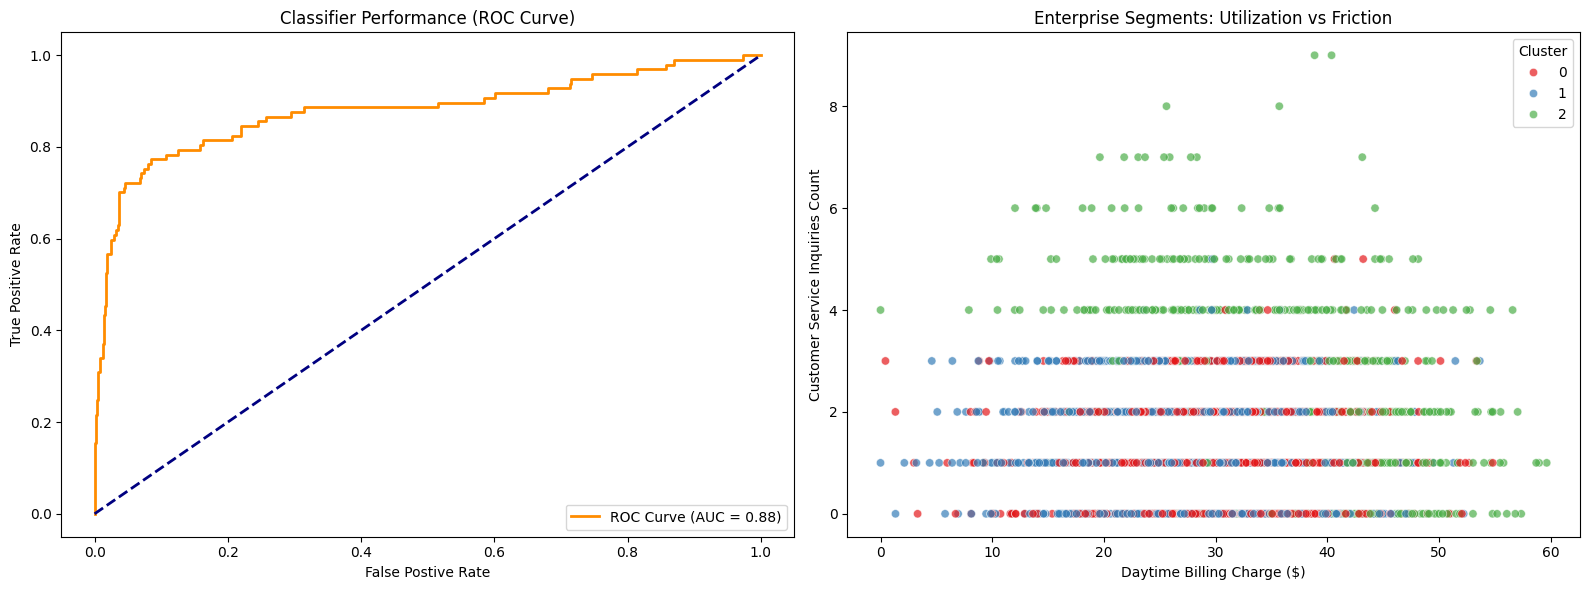

In [17]:
print("\n--- [9/10] Saving Visual Metrics and Cluster Scatter Plots ---")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot ROC-AUC
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_xlabel('False Postive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Classifier Performance (ROC Curve)')
axes[0].legend(loc="lower right")

# Plot Customer Segments
sns.scatterplot(
    data=df_clean, x='Day Charge', y='CustServ Calls',
    hue='Cluster', palette='Set1', ax=axes[1], alpha=0.7
)
axes[1].set_title('Enterprise Segments: Utilization vs Friction')
axes[1].set_xlabel('Daytime Billing Charge ($)')
axes[1].set_ylabel('Customer Service Inquiries Count')

plt.tight_layout()
plt.savefig('telecom_churn_pipeline_output.png', dpi=300)
print("Pipeline graphic successfully saved as 'telecom_churn_pipeline_output.png'")